# Stage 1 Outline: Frozen DINOv2 + Learned Upsampler + Shallow ResNet18 (Tiled)

This notebook now uses the architecture we discussed:

1. Tile images into native chips (`224` or `448`) with overlap
2. Build supervision targets from LabelMe vehicle polygons
3. Extract features from:
   - frozen **DINOv2** tokens (semantic branch)
   - **ResNet18 stem + layer1** only (local low-level branch)
4. Learn to upsample DINO features and fuse with shallow ResNet features
5. Predict proposal/objectness maps (+ optional box offsets)
6. Train for high recall proposal generation

This is an implementation-oriented outline with executable scaffolding.


In [59]:
from pathlib import Path
import json
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from tqdm.auto import tqdm


In [60]:
# -------------------------
# Config
# -------------------------

@dataclass
class Cfg:
    repo_root: Path = Path.cwd()
    data_dir: Path = Path.cwd() / "data" / "record_pairs"

    tile_size: int = 224
    tile_stride: int = 112

    label_name: str = "vehicle"
    min_poly_points: int = 3

    batch_size: int = 8
    num_workers: int = 8
    epochs: int = 25
    lr: float = 5e-5
    weight_decay: float = 1e-4

    # model
    fusion_channels: int = 256
    use_box_head: bool = False

    # segmentation target
    seg_out_stride: int = 4

    # sampling
    balance_train_50_50: bool = True
    balance_val_50_50: bool = False

cfg = Cfg()
assert cfg.data_dir.exists(), f"Missing {cfg.data_dir}"
print(cfg)


Cfg(repo_root=PosixPath('/home/schelli/git/wtcv'), data_dir=PosixPath('/home/schelli/git/wtcv/data/record_pairs'), tile_size=224, tile_stride=112, label_name='vehicle', min_poly_points=3, batch_size=8, num_workers=8, epochs=25, lr=5e-05, weight_decay=0.0001, fusion_channels=256, use_box_head=False, seg_out_stride=4, balance_train_50_50=True, balance_val_50_50=False)


In [61]:
# -------------------------
# Label parsing + geometry
# -------------------------

def polygon_area(points: List[List[float]]) -> float:
    if len(points) < 3:
        return 0.0
    x = np.array([p[0] for p in points], dtype=np.float32)
    y = np.array([p[1] for p in points], dtype=np.float32)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_bbox(points: List[List[float]]) -> Tuple[float, float, float, float]:
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return min(xs), min(ys), max(xs), max(ys)


def polygon_center(points: List[List[float]]) -> Tuple[float, float]:
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return float(np.mean(xs)), float(np.mean(ys))


def load_records(data_dir: Path, label_name: str = "vehicle") -> List[Dict]:
    records = []
    for jf in sorted(data_dir.glob("*.json")):
        img_path = data_dir / f"{jf.stem}.png"
        if not img_path.exists():
            continue

        d = json.loads(jf.read_text())
        w = d.get("imageWidth")
        h = d.get("imageHeight")
        shapes = d.get("shapes", []) or []

        objects = []
        for s in shapes:
            if s.get("label") != label_name:
                continue
            pts = s.get("points") or []
            if len(pts) < cfg.min_poly_points:
                continue
            x0, y0, x1, y1 = polygon_bbox(pts)
            cx, cy = polygon_center(pts)
            objects.append({
                "points": pts,
                "bbox_xyxy": [x0, y0, x1, y1],
                "center_xy": [cx, cy],
                "poly_area": polygon_area(pts),
            })

        records.append({
            "image_path": str(img_path),
            "json_path": str(jf),
            "width": w,
            "height": h,
            "objects": objects,
        })
    return records

records = load_records(cfg.data_dir, cfg.label_name)
print("records:", len(records))
print("records_with_objects:", sum(1 for r in records if len(r["objects"]) > 0))
print("objects_total:", sum(len(r["objects"]) for r in records))


records: 224
records_with_objects: 224
objects_total: 338


In [62]:
# -------------------------
# Tiling utilities
# -------------------------

def tile_origins(width: int, height: int, tile: int, stride: int) -> List[Tuple[int, int]]:
    xs = list(range(0, max(1, width - tile + 1), stride))
    ys = list(range(0, max(1, height - tile + 1), stride))

    if len(xs) == 0 or xs[-1] != max(0, width - tile):
        xs.append(max(0, width - tile))
    if len(ys) == 0 or ys[-1] != max(0, height - tile):
        ys.append(max(0, height - tile))

    origins = [(x, y) for y in ys for x in xs]
    seen = set()
    out = []
    for o in origins:
        if o not in seen:
            out.append(o)
            seen.add(o)
    return out


def crop_with_pad(img: Image.Image, x0: int, y0: int, size: int) -> Image.Image:
    w, h = img.size
    x1, y1 = x0 + size, y0 + size

    sx0, sy0 = max(0, x0), max(0, y0)
    sx1, sy1 = min(w, x1), min(h, y1)

    crop = img.crop((sx0, sy0, sx1, sy1))
    out = Image.new("RGB", (size, size), (0, 0, 0))
    out.paste(crop, (sx0 - x0, sy0 - y0))
    return out


def objects_in_tile(objs: List[Dict], x0: int, y0: int, size: int) -> List[Dict]:
    # keep any object with bbox intersection with tile; shift polygon points to tile coords
    x1, y1 = x0 + size, y0 + size
    out = []
    for o in objs:
        bx0, by0, bx1, by1 = o["bbox_xyxy"]
        intersects = not (bx1 < x0 or bx0 > x1 or by1 < y0 or by0 > y1)
        if not intersects:
            continue

        shifted_points = [[float(px - x0), float(py - y0)] for px, py in o["points"]]
        cx, cy = o["center_xy"]
        out.append({
            "points": shifted_points,
            "center_xy": [cx - x0, cy - y0],
            "bbox_xyxy": [bx0 - x0, by0 - y0, bx1 - x0, by1 - y0],
            "poly_area": o["poly_area"],
        })
    return out


In [63]:
# -------------------------
# Target generation (segmentation mask from polygons)
# -------------------------

def build_seg_target(tile_size: int, objs: List[Dict], out_stride: int = 4) -> np.ndarray:
    # Draw binary mask at tile resolution, then downsample to model output grid.
    full = Image.new('L', (tile_size, tile_size), 0)
    draw = ImageDraw.Draw(full)

    for o in objs:
        pts = o.get('points', [])
        if len(pts) >= 3:
            draw.polygon([(p[0], p[1]) for p in pts], fill=1)

    full_np = np.array(full, dtype=np.float32)  # [H,W] in {0,1}

    H = tile_size // out_stride
    W = tile_size // out_stride

    t = torch.from_numpy(full_np).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    # max-pool style downsample to preserve tiny positives
    t = F.interpolate(t, size=(H, W), mode='nearest')
    seg = t[0, 0].numpy().astype(np.float32)
    return seg


In [64]:
# -------------------------
# Dataset for tiled segmentation training
# -------------------------

class ProposalTileDataset(Dataset):
    def __init__(self, records: List[Dict], tile_size: int, stride: int, train: bool = True, balance_50_50: bool = False):
        self.records = records
        self.tile_size = tile_size
        self.stride = stride
        self.train = train
        self.balance_50_50 = balance_50_50

        all_index = []
        pos_index = []
        neg_index = []

        for ridx, r in enumerate(records):
            W, H = r["width"], r["height"]
            for x0, y0 in tile_origins(W, H, tile_size, stride):
                objs = objects_in_tile(r["objects"], x0, y0, tile_size)
                item = (ridx, x0, y0)
                all_index.append(item)
                if len(objs) > 0:
                    pos_index.append(item)
                else:
                    neg_index.append(item)

        if self.balance_50_50 and len(pos_index) > 0 and len(neg_index) > 0:
            n = min(len(pos_index), len(neg_index))
            rng = np.random.default_rng(SEED)
            pos_sel = rng.choice(len(pos_index), size=n, replace=False)
            neg_sel = rng.choice(len(neg_index), size=n, replace=False)
            self.index = [pos_index[i] for i in pos_sel] + [neg_index[i] for i in neg_sel]
            rng.shuffle(self.index)
            print(f"Balanced dataset enabled: pos={n}, neg={n}, total={len(self.index)}")
        else:
            self.index = all_index
            print(f"Unbalanced dataset: total={len(self.index)} (pos={len(pos_index)}, neg={len(neg_index)})")

        self.normalize = torchvision.transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        )

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        ridx, x0, y0 = self.index[idx]
        r = self.records[ridx]

        img = Image.open(r["image_path"]).convert("RGB")
        tile = crop_with_pad(img, x0, y0, self.tile_size)

        objs = objects_in_tile(r["objects"], x0, y0, self.tile_size)
        seg_t = build_seg_target(self.tile_size, objs, out_stride=cfg.seg_out_stride)

        x = TF.to_tensor(tile)
        x = self.normalize(x)

        sample = {
            "image": x,
            "seg_target": torch.from_numpy(seg_t).unsqueeze(0),      # [1,H,W]
            "meta": {
                "image_path": r["image_path"],
                "tile_origin": (x0, y0),
                "num_objects": len(objs),
                "is_positive_tile": int(len(objs) > 0),
            },
        }
        return sample

split = int(0.9 * len(records))
train_records = records[:split]
val_records = records[split:]

train_ds = ProposalTileDataset(
    train_records,
    cfg.tile_size,
    cfg.tile_stride,
    train=True,
    balance_50_50=cfg.balance_train_50_50,
)
val_ds = ProposalTileDataset(
    val_records,
    cfg.tile_size,
    cfg.tile_stride,
    train=False,
    balance_50_50=cfg.balance_val_50_50,
)

print("train tiles:", len(train_ds))
print("val tiles:", len(val_ds))

sample = train_ds[0]
print(sample["image"].shape, sample["seg_target"].shape)


Balanced dataset enabled: pos=1210, neg=1210, total=2420
Unbalanced dataset: total=1518 (pos=112, neg=1406)
train tiles: 2420
val tiles: 1518
torch.Size([3, 224, 224]) torch.Size([1, 56, 56])


In [65]:
# -------------------------
# Model: frozen DINOv2 + learned upsample blocks + shallow ResNet18 + 1x1 fusion + segmentation head
# -------------------------

class FrozenDinoTokenBranch(nn.Module):
    def __init__(self, out_channels: int = 256):
        super().__init__()
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone.eval()

        # DINOv2 ViT-S token dim
        self.proj = nn.Conv2d(384, out_channels, kernel_size=1)

    @torch.no_grad()
    def forward(self, x):
        self.backbone.eval()
        feats = self.backbone.forward_features(x)
        tokens = feats['x_norm_patchtokens']  # [B, N, 384]
        b, n, c = tokens.shape
        h = w = int(math.sqrt(n))
        fmap = tokens.transpose(1, 2).reshape(b, c, h, w)  # [B,384,h,w]
        fmap = self.proj(fmap)                             # [B,C,h,w]
        return fmap


class DinoLearnedUpsampler(nn.Module):
    # Upsample/Conv/GELU blocks: no transposed convolutions.
    def __init__(self, channels: int = 256):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.act1 = nn.GELU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.act2 = nn.GELU()

    def forward(self, x, target_hw):
        # Block 1
        x = F.interpolate(x, scale_factor=2.0, mode='bilinear', align_corners=False)
        x = self.act1(self.conv1(x))

        # Block 2
        x = F.interpolate(x, scale_factor=2.0, mode='bilinear', align_corners=False)
        x = self.act2(self.conv2(x))

        # Final align to local branch spatial size
        if x.shape[-2:] != target_hw:
            x = F.interpolate(x, size=target_hw, mode='bilinear', align_corners=False)
        return x


class ResNet18LocalBranch(nn.Module):
    # Local low-level branch: stem + layer1 only.
    def __init__(self, out_channels: int = 256):
        super().__init__()
        m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)

        self.stem = nn.Sequential(m.conv1, m.bn1, m.relu, m.maxpool)  # -> stride 4
        self.l1 = m.layer1                                             # -> stride 4

        self.proj = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.stem(x)
        x = self.l1(x)
        x = self.proj(x)
        return x


class SegmentationHead(nn.Module):
    def __init__(self, channels: int = 256):
        super().__init__()
        self.seg_head = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, 1, 1),
        )

    def forward(self, x):
        return {"seg_logit": self.seg_head(x)}


class Stage1ProposalNet(nn.Module):
    def __init__(self, channels=256, use_box_head=False):
        super().__init__()
        self.dino = FrozenDinoTokenBranch(channels)
        self.dino_up = DinoLearnedUpsampler(channels)
        self.local = ResNet18LocalBranch(channels)

        # Simple fusion: concat at same spatial size, then 1x1 conv
        self.fuse_1x1 = nn.Conv2d(channels * 2, channels, kernel_size=1)
        self.head = SegmentationHead(channels)

    def forward(self, x):
        fdino = self.dino(x)
        flocal = self.local(x)

        fdino_up = self.dino_up(fdino, target_hw=flocal.shape[-2:])

        fused = torch.cat([fdino_up, flocal], dim=1)
        fused = self.fuse_1x1(fused)

        out = self.head(fused)

        # enforce exact target shape used by dataset target builder (stride 4)
        target_hw = (x.shape[-2] // 4, x.shape[-1] // 4)
        out["seg_logit"] = F.interpolate(out["seg_logit"], size=target_hw, mode='bilinear', align_corners=False)
        return out


In [66]:
# -------------------------
# Losses + metrics (MCC loss + Mask IoU metric)
# -------------------------

def mcc_loss_with_logits(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7):
    # logits/targets: [B,1,H,W]
    probs = torch.sigmoid(logits)
    targets = targets.float()

    probs = probs.view(probs.shape[0], -1)
    targets = targets.view(targets.shape[0], -1)

    tp = (probs * targets).sum(dim=1)
    tn = ((1 - probs) * (1 - targets)).sum(dim=1)
    fp = (probs * (1 - targets)).sum(dim=1)
    fn = ((1 - probs) * targets).sum(dim=1)

    numerator = tp * tn - fp * fn
    denominator = torch.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn) + eps)
    mcc = numerator / (denominator + eps)
    return 1.0 - mcc.mean()


def compute_losses(pred, batch):
    seg_t = batch['seg_target'].to(pred['seg_logit'].device)
    seg_loss = mcc_loss_with_logits(pred['seg_logit'], seg_t)
    return {'seg_mcc_loss': seg_loss, 'total': seg_loss}


def mask_iou_at_threshold(pred_logit: torch.Tensor, seg_target: torch.Tensor, thr: float = 0.5, eps: float = 1e-7):
    # pred_logit/seg_target: [B,1,H,W]
    pred = (torch.sigmoid(pred_logit) > thr).float()
    tgt = seg_target.float()

    pred = pred.view(pred.shape[0], -1)
    tgt = tgt.view(tgt.shape[0], -1)

    inter = (pred * tgt).sum(dim=1)
    union = ((pred + tgt) > 0).float().sum(dim=1)
    iou = inter / (union + eps)
    return float(iou.mean().item())


In [67]:
# -------------------------
# Train/val scaffolding
# -------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

model = Stage1ProposalNet(channels=cfg.fusion_channels, use_box_head=False).to(device)

# freeze DINO branch parameters explicitly
for p in model.dino.parameters():
    p.requires_grad = False

optim_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(optim_params, lr=cfg.lr, weight_decay=cfg.weight_decay)

print('trainable params:', sum(p.numel() for p in optim_params))


device: cuda


Using cache found in /home/schelli/.cache/torch/hub/facebookresearch_dinov2_main


trainable params: 2075969


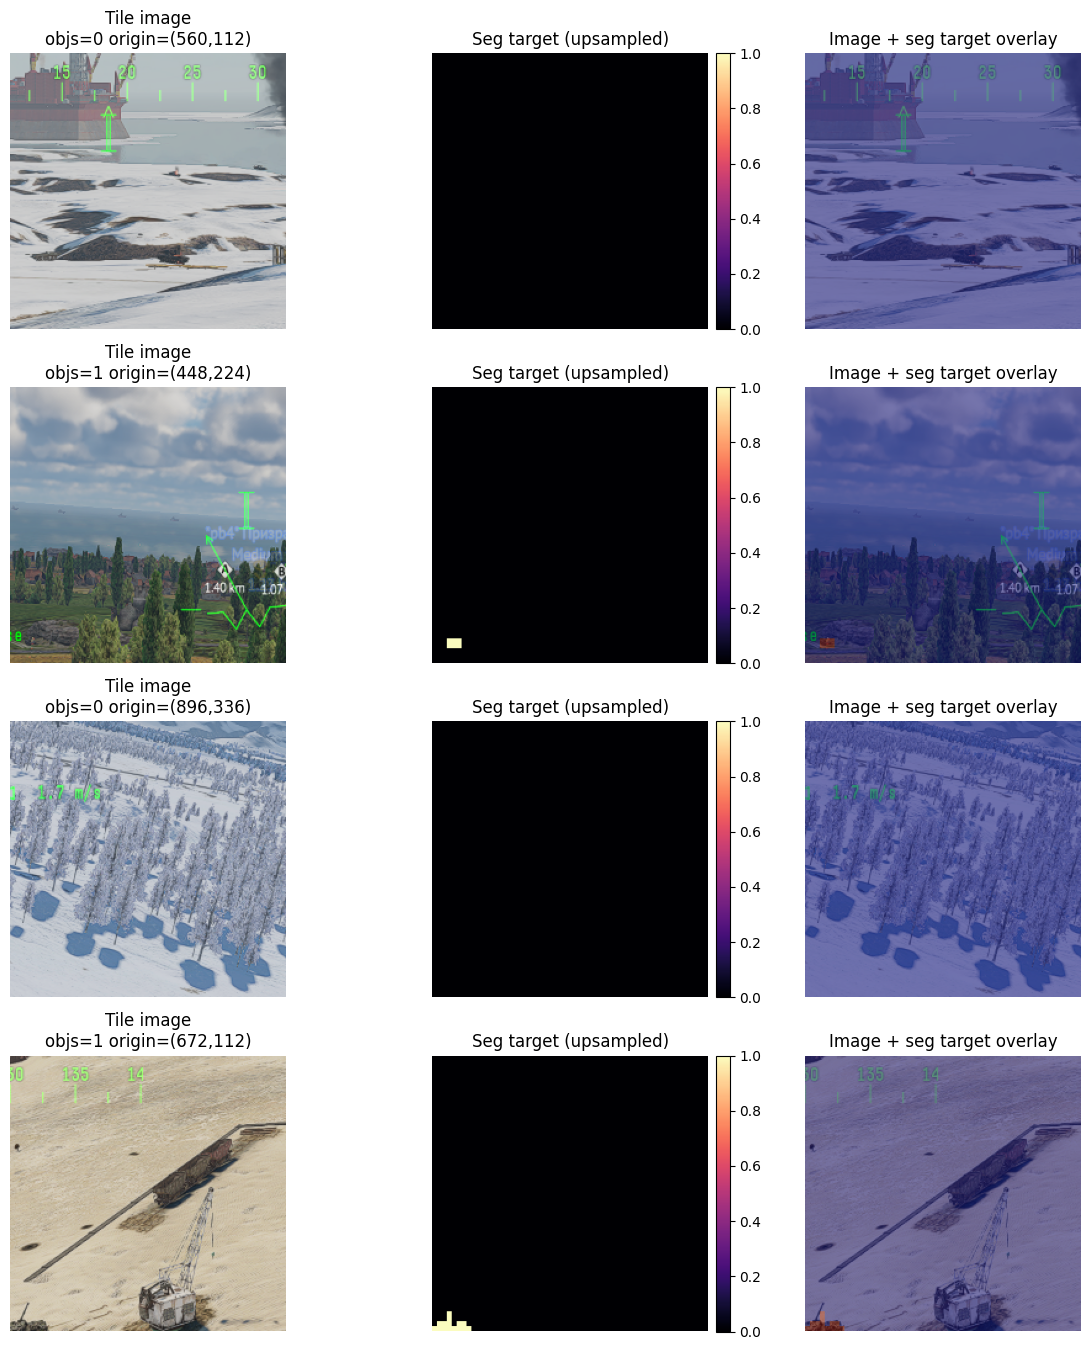

In [68]:
# -------------------------
# Visualization helpers: train examples with segmentation targets
# -------------------------

def unnormalize_image(x: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=x.dtype, device=x.device).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=x.dtype, device=x.device).view(3,1,1)
    y = (x * std + mean).clamp(0, 1)
    return y.permute(1,2,0).cpu().numpy()


def upsample_map_to_image(map_2d: np.ndarray, out_hw: tuple[int, int]) -> np.ndarray:
    t = torch.from_numpy(map_2d).float().unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=out_hw, mode='nearest')
    return t[0, 0].numpy()


def plot_train_examples_with_targets(dataset: Dataset, n: int = 4):
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    fig, axes = plt.subplots(len(idxs), 3, figsize=(12, 3.4 * len(idxs)))
    if len(idxs) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, idx in enumerate(idxs):
        s = dataset[int(idx)]
        img = unnormalize_image(s['image'])
        H, W = img.shape[:2]

        seg_t = s['seg_target'][0].numpy()
        seg_up = upsample_map_to_image(seg_t, (H, W))

        num_obj = s['meta']['num_objects']
        x0, y0 = s['meta']['tile_origin']

        axes[r, 0].imshow(img)
        axes[r, 0].set_title(f"Tile image\nobjs={num_obj} origin=({x0},{y0})")
        axes[r, 0].axis('off')

        im1 = axes[r, 1].imshow(seg_up, cmap='magma', vmin=0.0, vmax=1.0)
        axes[r, 1].set_title('Seg target (upsampled)')
        axes[r, 1].axis('off')
        fig.colorbar(im1, ax=axes[r, 1], fraction=0.046, pad=0.02)

        axes[r, 2].imshow(img)
        axes[r, 2].imshow(seg_up, cmap='jet', alpha=0.45, vmin=0.0, vmax=1.0)
        axes[r, 2].set_title('Image + seg target overlay')
        axes[r, 2].axis('off')

    plt.tight_layout()
    plt.show()


plot_train_examples_with_targets(train_ds, n=4)


epoch=01 train_total=0.8465 train_iou=0.1058 val_total=0.9641 val_iou=0.0265
Training batch visualization at epoch 1


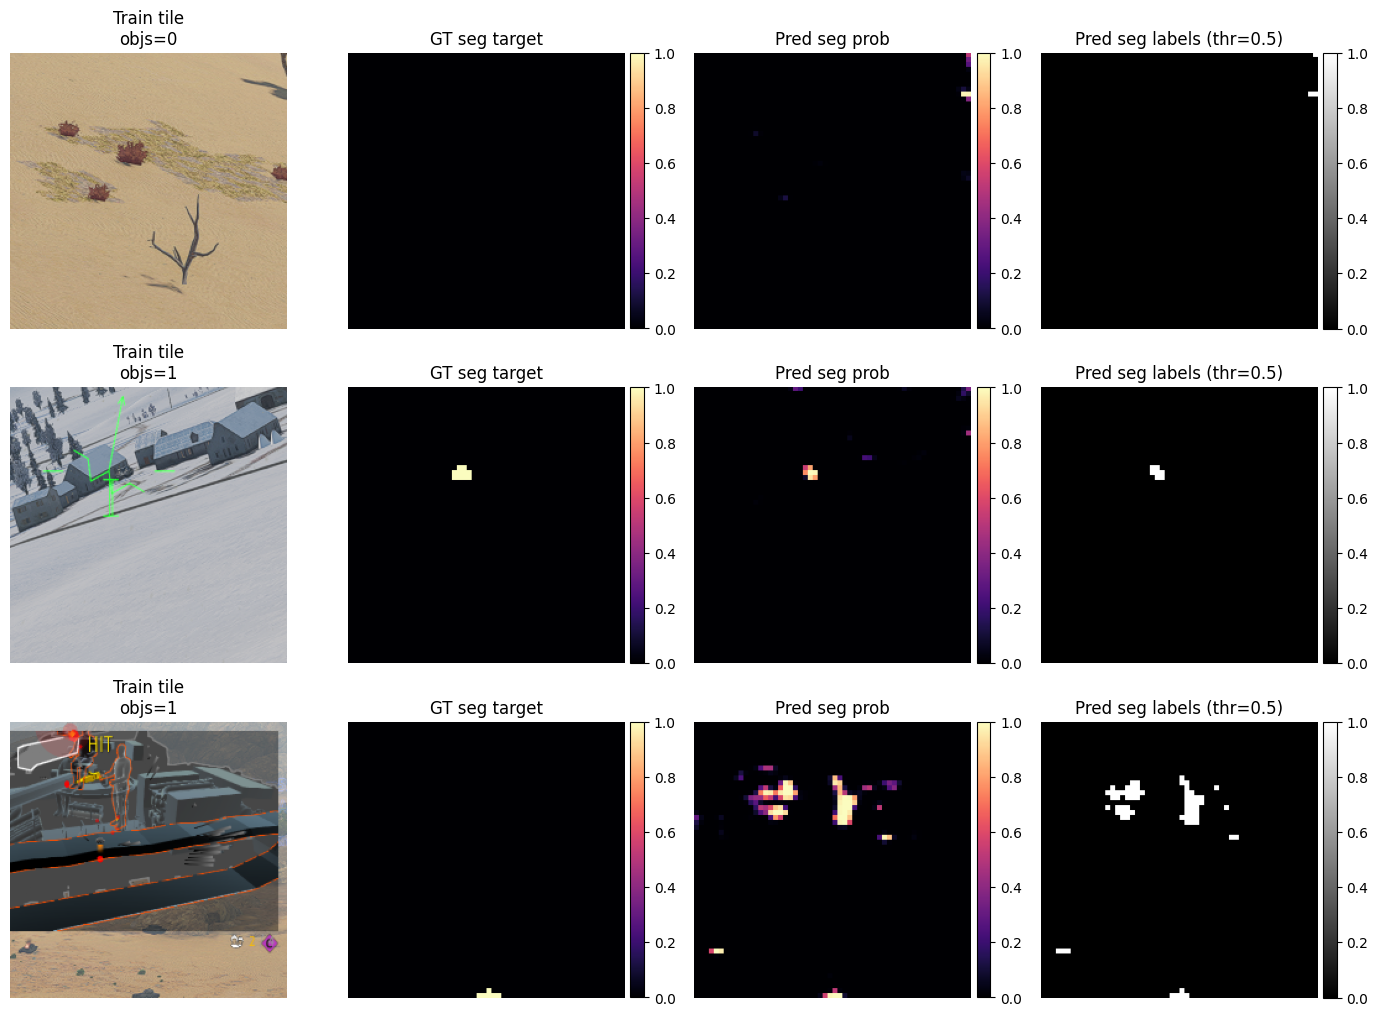

Validation visualization at epoch 1


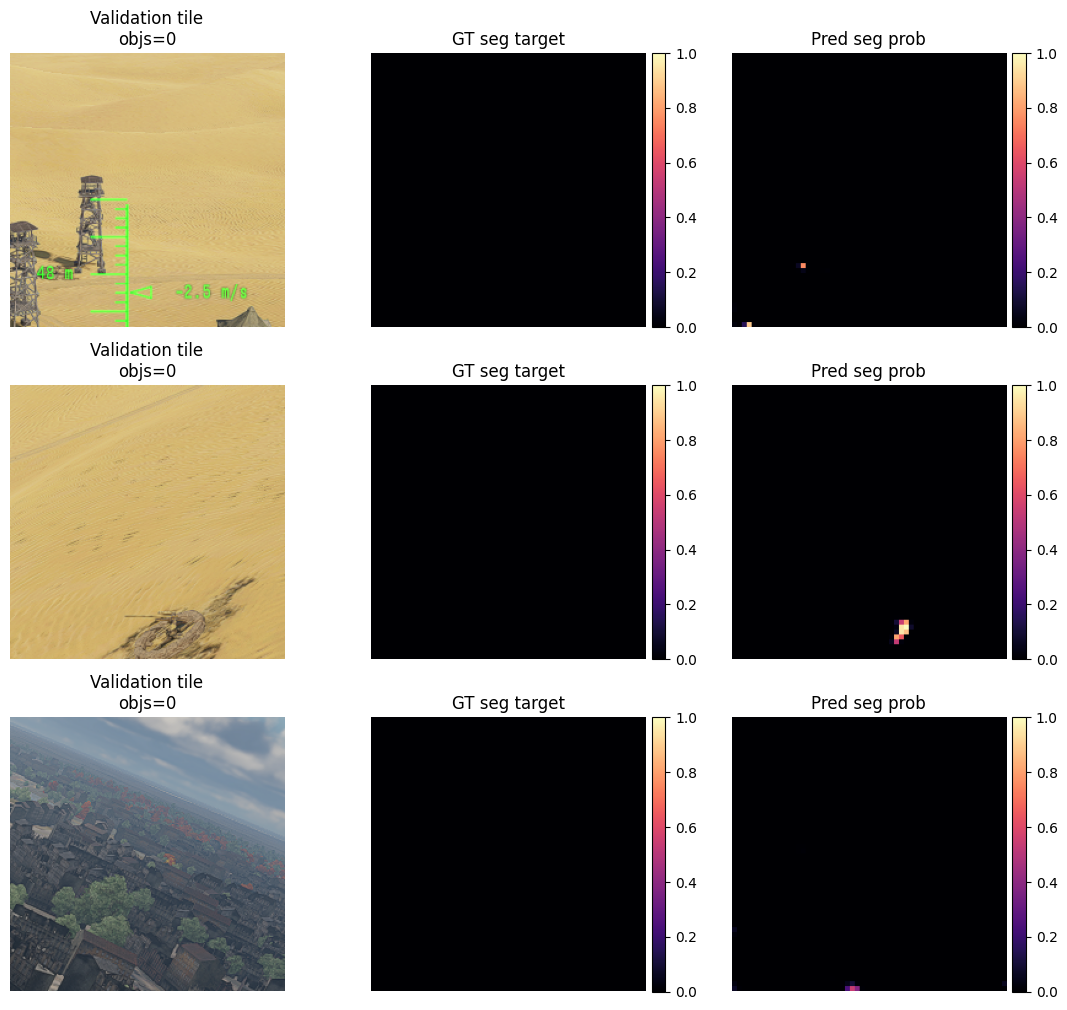

epoch=02 train_total=0.7631 train_iou=0.1750 val_total=0.9624 val_iou=0.0274
Training batch visualization at epoch 2


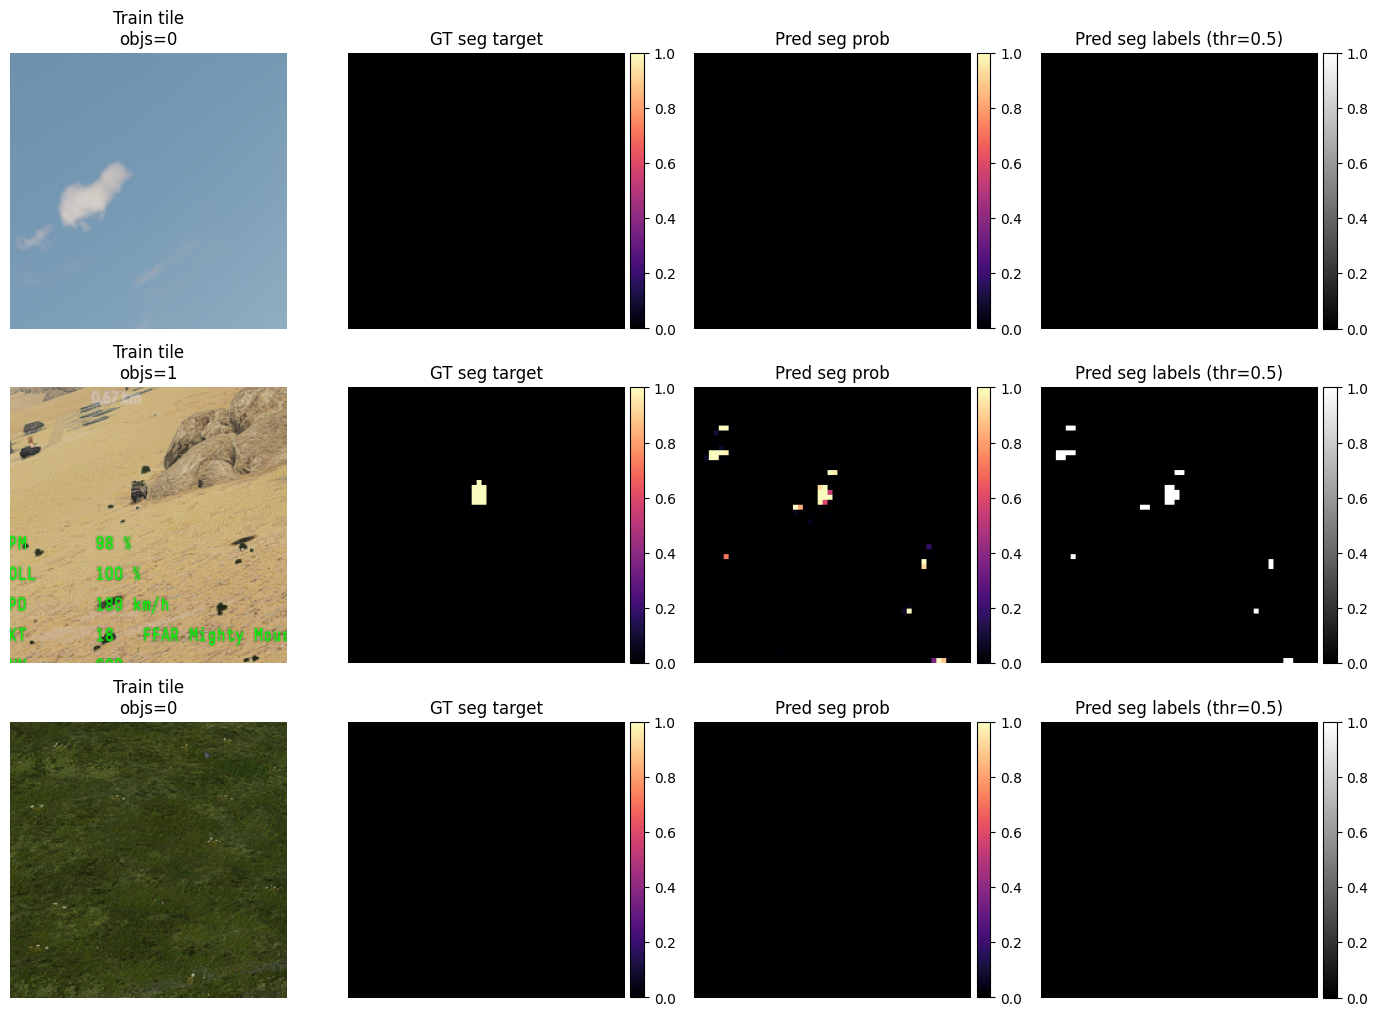

Validation visualization at epoch 2


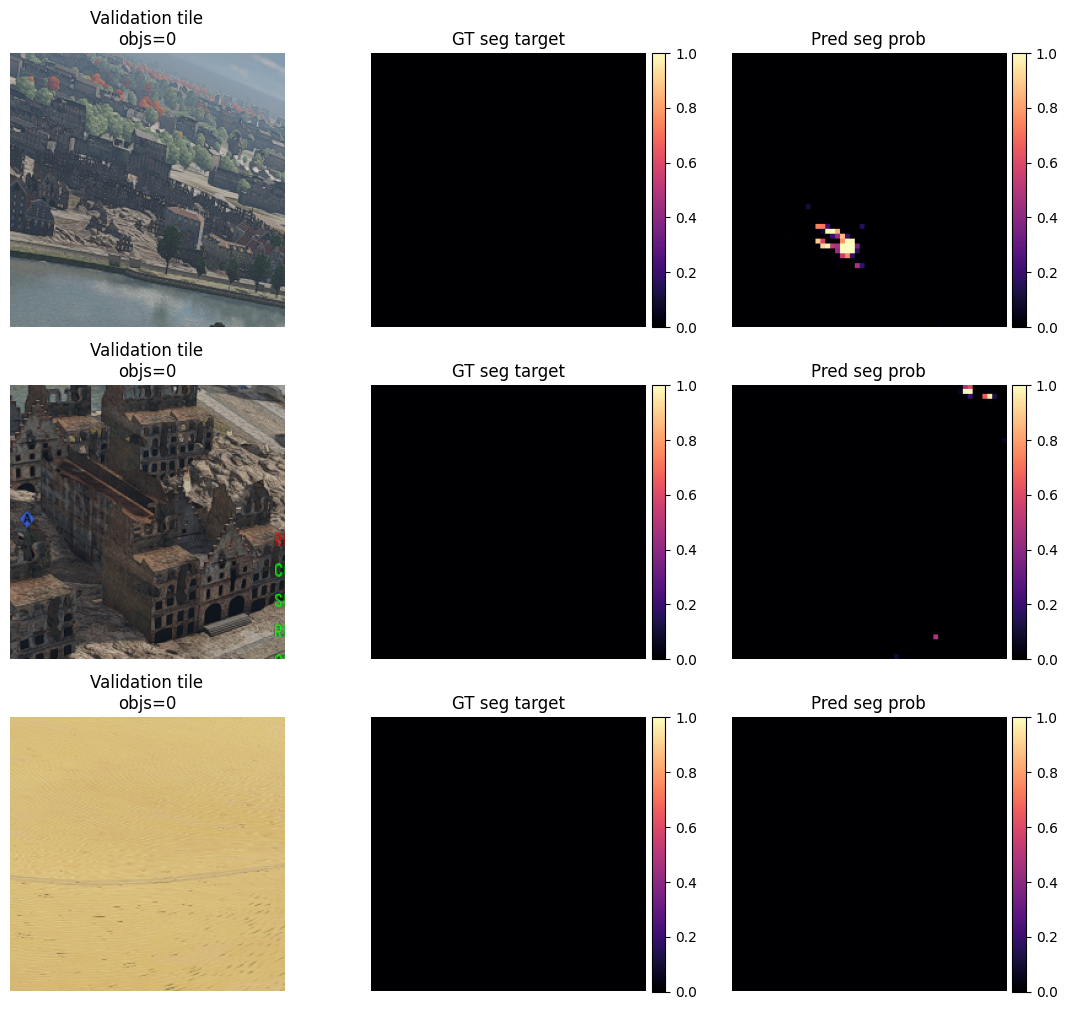

KeyboardInterrupt: 

In [69]:
# -------------------------
# Execution logic: train + validation each epoch
# -------------------------

def run_epoch(loader, train=True, epoch: int = 0, split_name: str = 'train'):
    model.train(train)
    if not train:
        model.eval()

    total_losses = []
    iou_scores = []

    pbar = tqdm(loader, desc=f"{split_name} epoch {epoch:02d}", leave=False)
    for batch in pbar:
        x = batch['image'].to(device)

        with torch.set_grad_enabled(train):
            pred = model(x)
            losses = compute_losses(pred, batch)

            if train:
                optimizer.zero_grad(set_to_none=True)
                losses['total'].backward()
                optimizer.step()

        total_losses.append(float(losses['total'].detach().cpu()))
        iou = mask_iou_at_threshold(pred['seg_logit'].detach(), batch['seg_target'].to(device), thr=0.5)
        iou_scores.append(iou)

        pbar.set_postfix({'loss': f"{total_losses[-1]:.4f}", 'iou': f"{iou:.3f}"})

    return {
        'total_loss': float(np.mean(total_losses)) if total_losses else float('nan'),
        'mask_iou': float(np.mean(iou_scores)) if iou_scores else float('nan'),
    }


def plot_train_batch_example(model, loader, max_items: int = 3, thr: float = 0.5):
    model.eval()
    ds = loader.dataset
    n = min(max_items, len(ds))
    idxs = np.random.choice(len(ds), size=n, replace=False)

    images, targets, metas = [], [], []
    for idx in idxs:
        sample = ds[int(idx)]
        images.append(sample['image'])
        targets.append(sample['seg_target'])
        metas.append(sample['meta'])

    x = torch.stack(images, dim=0).to(device)
    seg_t = torch.stack(targets, dim=0)

    with torch.no_grad():
        pred = model(x)
        seg_p = torch.sigmoid(pred['seg_logit']).detach().cpu()

    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = unnormalize_image(x[i].detach().cpu())
        gt = seg_t[i, 0].numpy()
        pr = seg_p[i, 0].numpy()
        gt_up = upsample_map_to_image(gt, img.shape[:2])
        pr_up = upsample_map_to_image(pr, img.shape[:2])
        lb = (pr_up > thr).astype(np.float32)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Train tile\nobjs={metas[i]['num_objects']}")
        axes[i, 0].axis('off')

        im1 = axes[i, 1].imshow(gt_up, cmap='magma', vmin=0.0, vmax=1.0)
        axes[i, 1].set_title('GT seg target')
        axes[i, 1].axis('off')
        fig.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.02)

        im2 = axes[i, 2].imshow(pr_up, cmap='magma', vmin=0.0, vmax=1.0)
        axes[i, 2].set_title('Pred seg prob')
        axes[i, 2].axis('off')
        fig.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.02)

        im3 = axes[i, 3].imshow(lb, cmap='gray', vmin=0.0, vmax=1.0)
        axes[i, 3].set_title(f'Pred seg labels (thr={thr})')
        axes[i, 3].axis('off')
        fig.colorbar(im3, ax=axes[i, 3], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


def plot_val_predictions(model, loader, max_items: int = 3):
    model.eval()
    ds = loader.dataset
    n = min(max_items, len(ds))
    idxs = np.random.choice(len(ds), size=n, replace=False)

    images, targets, metas = [], [], []
    for idx in idxs:
        s = ds[int(idx)]
        images.append(s['image'])
        targets.append(s['seg_target'])
        metas.append(s['meta'])

    x = torch.stack(images, dim=0).to(device)
    seg_t = torch.stack(targets, dim=0)

    with torch.no_grad():
        pred = model(x)
        seg_p = torch.sigmoid(pred['seg_logit']).detach().cpu()

    fig, axes = plt.subplots(n, 3, figsize=(11, 3.4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = unnormalize_image(x[i].detach().cpu())
        gt = seg_t[i, 0].numpy()
        pr = seg_p[i, 0].numpy()
        gt_up = upsample_map_to_image(gt, img.shape[:2])
        pr_up = upsample_map_to_image(pr, img.shape[:2])

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Validation tile\nobjs={metas[i]['num_objects']}")
        axes[i, 0].axis('off')

        im1 = axes[i, 1].imshow(gt_up, cmap='magma', vmin=0.0, vmax=1.0)
        axes[i, 1].set_title('GT seg target')
        axes[i, 1].axis('off')
        fig.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.02)

        im2 = axes[i, 2].imshow(pr_up, cmap='magma', vmin=0.0, vmax=1.0)
        axes[i, 2].set_title('Pred seg prob')
        axes[i, 2].axis('off')
        fig.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


RUN_TRAINING = True
PLOT_TRAIN_EVERY_EPOCH = True
PLOT_VAL_EVERY_EPOCH = True

history = []

if RUN_TRAINING:
    for epoch in range(1, cfg.epochs + 1):
        tr = run_epoch(train_loader, train=True, epoch=epoch, split_name='train')
        va = run_epoch(val_loader, train=False, epoch=epoch, split_name='val')

        row = {
            'epoch': epoch,
            'train_total': tr['total_loss'],
            'train_iou': tr['mask_iou'],
            'val_total': va['total_loss'],
            'val_iou': va['mask_iou'],
        }
        history.append(row)

        print(
            f"epoch={epoch:02d} "
            f"train_total={row['train_total']:.4f} train_iou={row['train_iou']:.4f} "
            f"val_total={row['val_total']:.4f} val_iou={row['val_iou']:.4f}"
        )

        if PLOT_TRAIN_EVERY_EPOCH:
            print(f"Training batch visualization at epoch {epoch}")
            plot_train_batch_example(model, train_loader, max_items=3, thr=0.5)

        if PLOT_VAL_EVERY_EPOCH:
            print(f"Validation visualization at epoch {epoch}")
            plot_val_predictions(model, val_loader, max_items=3)


if len(history) > 0:
    epochs = [h['epoch'] for h in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [h['train_total'] for h in history], label='train_total')
    axes[0].plot(epochs, [h['val_total'] for h in history], label='val_total')
    axes[0].set_title('MCC Loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    axes[1].plot(epochs, [h['train_iou'] for h in history], label='train_iou')
    axes[1].plot(epochs, [h['val_iou'] for h in history], label='val_iou')
    axes[1].set_title('Mask IoU metric')
    axes[1].set_xlabel('epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
# -------------------------
# Inference helper for Stage-1 segmentation on one full image
# -------------------------

def infer_segmentation_on_image(model, image_path: Path, tile_size: int, stride: int):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    W, H = img.size

    GH, GW = H // cfg.seg_out_stride, W // cfg.seg_out_stride
    accum = np.zeros((GH, GW), dtype=np.float32)
    count = np.zeros((GH, GW), dtype=np.float32)

    norm = torchvision.transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225))

    for x0, y0 in tile_origins(W, H, tile_size, stride):
        tile = crop_with_pad(img, x0, y0, tile_size)
        x = norm(TF.to_tensor(tile)).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(x)
            prob = torch.sigmoid(pred['seg_logit'])[0, 0].cpu().numpy()  # [tile/stride, tile/stride]

        th, tw = prob.shape
        gx0, gy0 = x0 // cfg.seg_out_stride, y0 // cfg.seg_out_stride
        gx1, gy1 = min(GW, gx0 + tw), min(GH, gy0 + th)

        accum[gy0:gy1, gx0:gx1] += prob[:gy1-gy0, :gx1-gx0]
        count[gy0:gy1, gx0:gx1] += 1.0

    merged = accum / np.maximum(count, 1e-6)
    return merged

# Example usage after training:
# seg_map = infer_segmentation_on_image(model, Path(records[0]['image_path']), cfg.tile_size, cfg.tile_stride)


## Notes For Stage 2 Handoff

Stage 1 now predicts a **segmentation map** for vehicle regions from polygon supervision,
using a simple MCC loss objective.

Current Stage 1 architecture keeps local features shallow:
1. frozen DINO semantics + learned DINO upsampler
2. ResNet18 low-level local detail (stem + layer1)
3. concat + 1x1 conv fusion for dense segmentation prediction

Stage 2 can consume top connected components / hotspots from the Stage-1 seg map.
